# Loading the full cleaned dataset

In [1]:
import pandas as pd

df = pd.read_csv('Course Analysis Cleaned Data.csv')
df.head()

,rating_workload,rating_content,rating_teaching,rating_grading,has_midterm,has_final,has_quiz,has_assignment,has_essay,has_project,has_attendance,has_reading,has_presentation,course_name,level,upvote_ratio,insturctor_rating
0,4,5,4,4,False,True,True,False,False,True,True,False,False,COMP1001,1000,NaN,0.0
1,3,3,3,3,True,True,False,False,False,True,False,False,False,COMP1001,1000,NaN,0.0
2,5,5,4,5,False,True,True,False,False,True,True,True,True,COMP1001,1000,NaN,0.0
3,5,5,5,5,False,True,True,False,False,True,True,False,True,COMP1001,1000,NaN,0.0
4,4,5,5,5,False,True,True,True,False,True,True,False,True,COMP1001,1000,NaN,0.0


In [2]:
df.info()
# contains null values in the columns of 'upvote_ratio' and 'instructor_rating'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1298 entries, 0 to 1297
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating_workload    1298 non-null   int64  
 1   rating_content     1298 non-null   int64  
 2   rating_teaching    1298 non-null   int64  
 3   rating_grading     1298 non-null   int64  
 4   has_midterm        1298 non-null   bool   
 5   has_final          1298 non-null   bool   
 6   has_quiz           1298 non-null   bool   
 7   has_assignment     1298 non-null   bool   
 8   has_essay          1298 non-null   bool   
 9   has_project        1298 non-null   bool   
 10  has_attendance     1298 non-null   bool   
 11  has_reading        1298 non-null   bool   
 12  has_presentation   1298 non-null   bool   
 13  course_name        1298 non-null   object 
 14  level              1298 non-null   int64  
 15  upvote_ratio       827 non-null    float64
 16  insturctor_rating  1220 

In [3]:
df.describe()

,rating_workload,rating_content,rating_teaching,rating_grading,level,upvote_ratio,insturctor_rating
count,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000,827.000000,1220.000000
mean,3.721109,4.141757,4.155624,4.044684,2466.101695,0.625220,7.008197
std,1.193997,1.056579,1.120553,1.156060,1239.608612,0.404406,4.952930
min,1.000000,1.000000,1.000000,1.000000,1000.000000,0.000000,0.000000
25%,3.000000,4.000000,4.000000,4.000000,1000.000000,0.200000,0.000000
50%,4.000000,4.000000,5.000000,4.000000,2000.000000,0.800000,11.000000
75%,5.000000,5.000000,5.000000,5.000000,3000.000000,1.000000,11.000000
max,5.000000,5.000000,5.000000,5.000000,5000.000000,1.000000,11.000000


# Prepare the Data for Training

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(['rating_content', 'rating_content', 'rating_teaching', 'rating_grading'], axis=1) # drop the columns of ratings to be used as targets
y = df['rating_workload'] # we will only focus on predicting the workload rating

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1038, 14) (260, 14) (1038,) (260,)


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

numerical_features = ['upvote_ratio', 'insturctor_rating']
categorical_features = list(X.select_dtypes(include=['bool']).columns)

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # choosing median because the mean will be skewed by the few very popular comments with a lot of upvotes, which will have a higher chance of receiving more upvotes as they will be shown at the top
    # ('scaler', StandardScaler()) # some samples will have their 'upvote_ratio' computed to be less than 0
    ('scaler', MinMaxScaler()) # so using min-max scaling to ensure the values are within the valid range
])

cat_pipeline = Pipeline([ 
    # no need for imputation because all columns are complete
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # 'level' = 1000 is NOT being dropped to avoid multicollinearity because it will be used to create new features later on
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, ['level']), # 'level' is the only features that needs to be one-hot encoded; the other features are already binary variables
    ('binary_cat', 'passthrough', categorical_features)
], remainder='drop')

# make sure to fit the preprocessor only on the training data to avoid data leakage
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
df_preprocessed = pd.DataFrame(X_train_preprocessed, columns=preprocessor.get_feature_names_out())

df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num__upvote_ratio             1038 non-null   float64
 1   num__insturctor_rating        1038 non-null   float64
 2   cat__level_1000               1038 non-null   float64
 3   cat__level_2000               1038 non-null   float64
 4   cat__level_3000               1038 non-null   float64
 5   cat__level_4000               1038 non-null   float64
 6   cat__level_5000               1038 non-null   float64
 7   binary_cat__has_midterm       1038 non-null   float64
 8   binary_cat__has_final         1038 non-null   float64
 9   binary_cat__has_quiz          1038 non-null   float64
 10  binary_cat__has_assignment    1038 non-null   float64
 11  binary_cat__has_essay         1038 non-null   float64
 12  binary_cat__has_project       1038 non-null   float64
 13  bin

In [18]:
df_preprocessed.describe()

,num__upvote_ratio,num__insturctor_rating,cat__level_1000,cat__level_2000,cat__level_3000,cat__level_4000,cat__level_5000,binary_cat__has_midterm,binary_cat__has_final,binary_cat__has_quiz,binary_cat__has_assignment,binary_cat__has_essay,binary_cat__has_project,binary_cat__has_attendance,binary_cat__has_reading,binary_cat__has_presentation
count,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000
mean,0.683330,0.653442,0.283237,0.259152,0.225434,0.171484,0.060694,0.685934,0.887283,0.176301,0.859345,0.028902,0.363198,0.291908,0.068401,0.109827
std,0.338131,0.447739,0.450788,0.438381,0.418069,0.377113,0.238883,0.464366,0.316399,0.381259,0.347833,0.167611,0.481153,0.454859,0.252554,0.312824
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,0.181818,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.800000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Feature Engineering (to create new interacting features)

In [19]:
# !pip install seaborn

<Axes: >

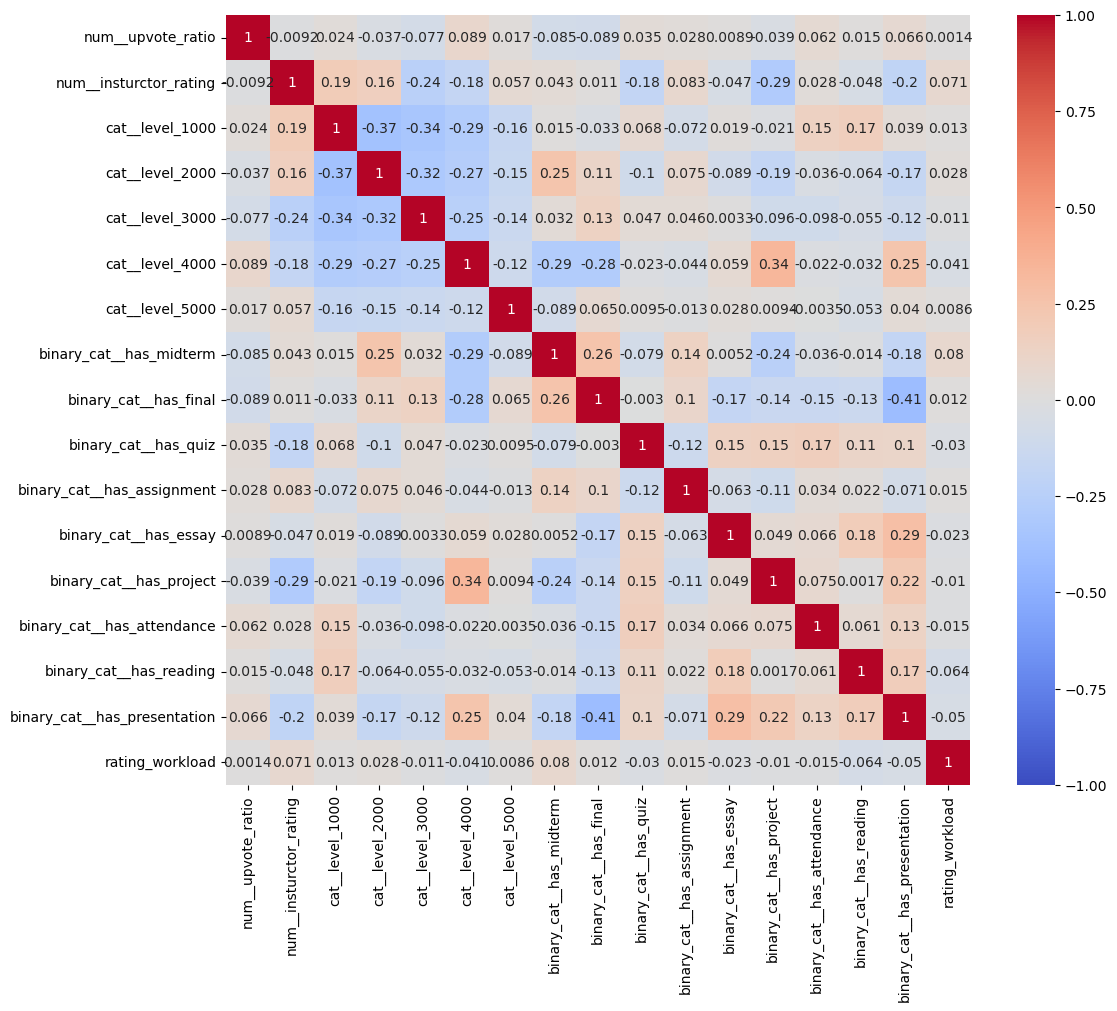

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

correlations = pd.concat([df_preprocessed, pd.DataFrame(y_train)], axis=1).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
# no features seem highly correlated with each other

In [21]:
# how much 'testing' does a course have?
df_preprocessed['quiz_and_exams'] = df_preprocessed['binary_cat__has_midterm'] + df_preprocessed['binary_cat__has_final'] + df_preprocessed['binary_cat__has_quiz']

# separating the course levels into two different buckets to capture the bigger picture ('is_higher_level' is represented by 'is_lower_level' being 0)
df_preprocessed['is_lower_level'] = (df_preprocessed['cat__level_1000'].astype('bool') | df_preprocessed['cat__level_2000'].astype('bool')).astype('float64')
# df_preprocessed['is_higher_level'] = (df_preprocessed['cat__level_3000'].astype('bool') | df_preprocessed['cat__level_4000'].astype('bool') | df_preprocessed['cat__level_5000'].astype('bool')).astype('float64')

# how much 'workload' does a course have?
df_preprocessed['sum_workload'] = df_preprocessed['binary_cat__has_assignment'] + df_preprocessed['binary_cat__has_project'] + df_preprocessed['binary_cat__has_essay'] + df_preprocessed['binary_cat__has_presentation'] + df_preprocessed['binary_cat__has_reading']

In [22]:
df_preprocessed.describe()

,num__upvote_ratio,num__insturctor_rating,cat__level_1000,cat__level_2000,cat__level_3000,cat__level_4000,cat__level_5000,binary_cat__has_midterm,binary_cat__has_final,binary_cat__has_quiz,binary_cat__has_assignment,binary_cat__has_essay,binary_cat__has_project,binary_cat__has_attendance,binary_cat__has_reading,binary_cat__has_presentation,quiz_and_exams,is_lower_level,sum_workload
count,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000
mean,0.683330,0.653442,0.283237,0.259152,0.225434,0.171484,0.060694,0.685934,0.887283,0.176301,0.859345,0.028902,0.363198,0.291908,0.068401,0.109827,1.749518,0.542389,1.429672
std,0.338131,0.447739,0.450788,0.438381,0.418069,0.377113,0.238883,0.464366,0.316399,0.381259,0.347833,0.167611,0.481153,0.454859,0.252554,0.312824,0.712794,0.498440,0.795580
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,0.181818,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,0.800000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,1.000000,2.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,5.000000


<Axes: >

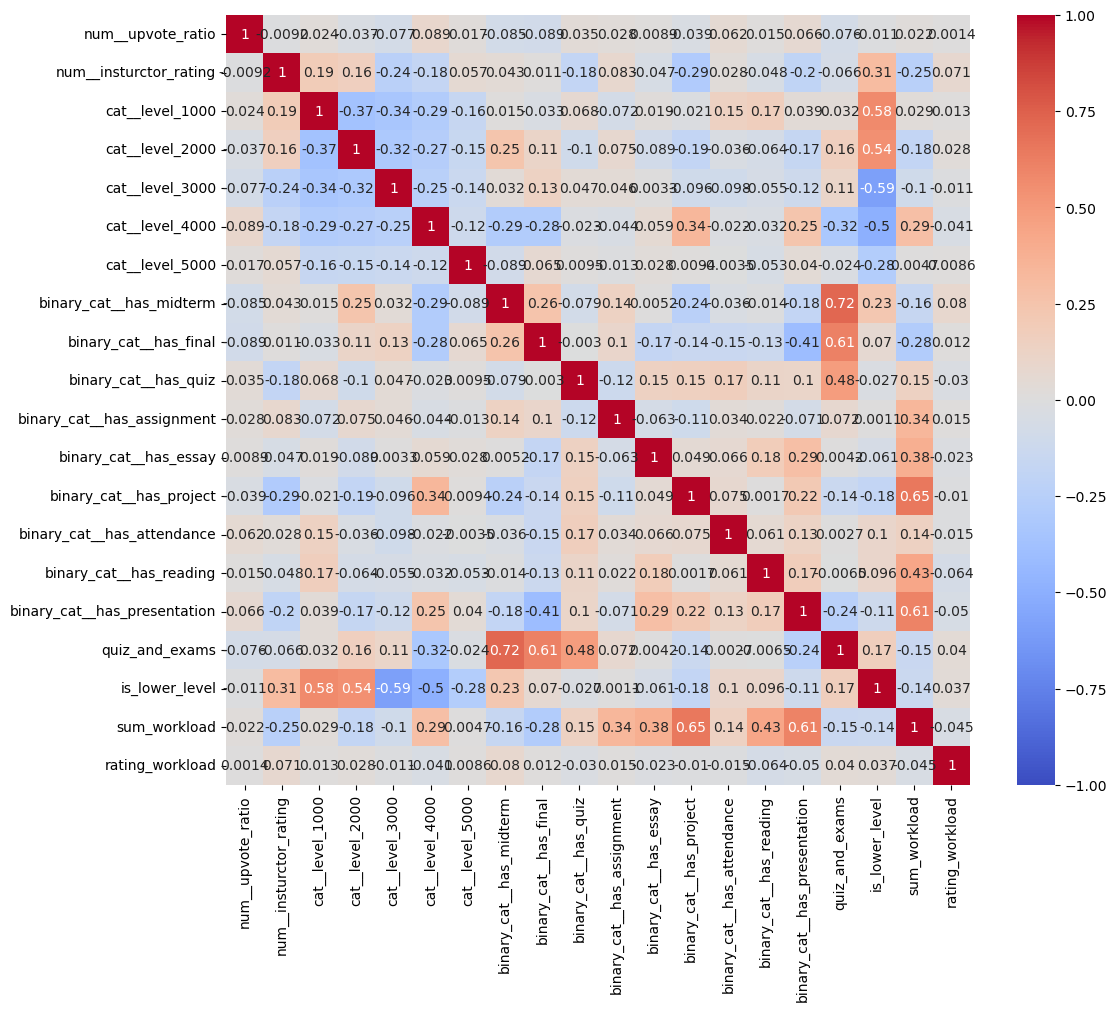

In [23]:
correlations = pd.concat([df_preprocessed, pd.DataFrame(y_train)], axis=1).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [24]:
# removing features that are now moderately (corr coef >= 0.5) correlated with the new engineered features to avoid multicollinearity
df_preprocessed.drop(columns=['cat__level_1000', 'cat__level_2000', 'cat__level_3000', 'cat__level_4000', 'binary_cat__has_midterm', 'binary_cat__has_final', 'binary_cat__has_project', 'binary_cat__has_presentation'], axis=1, inplace=True)

In [25]:
correlations = pd.concat([df_preprocessed, pd.DataFrame(y_train)], axis=1).corr()
target_corr = correlations['rating_workload'].sort_values(ascending=False).drop('rating_workload')
target_corr

num__insturctor_rating        0.071427
quiz_and_exams                0.040078
is_lower_level                0.036525
binary_cat__has_assignment    0.014518
cat__level_5000               0.008600
num__upvote_ratio             0.001401
binary_cat__has_attendance   -0.015078
binary_cat__has_essay        -0.023032
binary_cat__has_quiz         -0.030456
sum_workload                 -0.045315
binary_cat__has_reading      -0.064066
Name: rating_workload, dtype: float64

In [26]:
# dropping 'num__upvote_ratio' as it would be more helpful when used to determine the quality of the reviews for the NLP model
df_engineered = df_preprocessed.drop(['num__upvote_ratio'], axis=1)

# Explorative Analysis

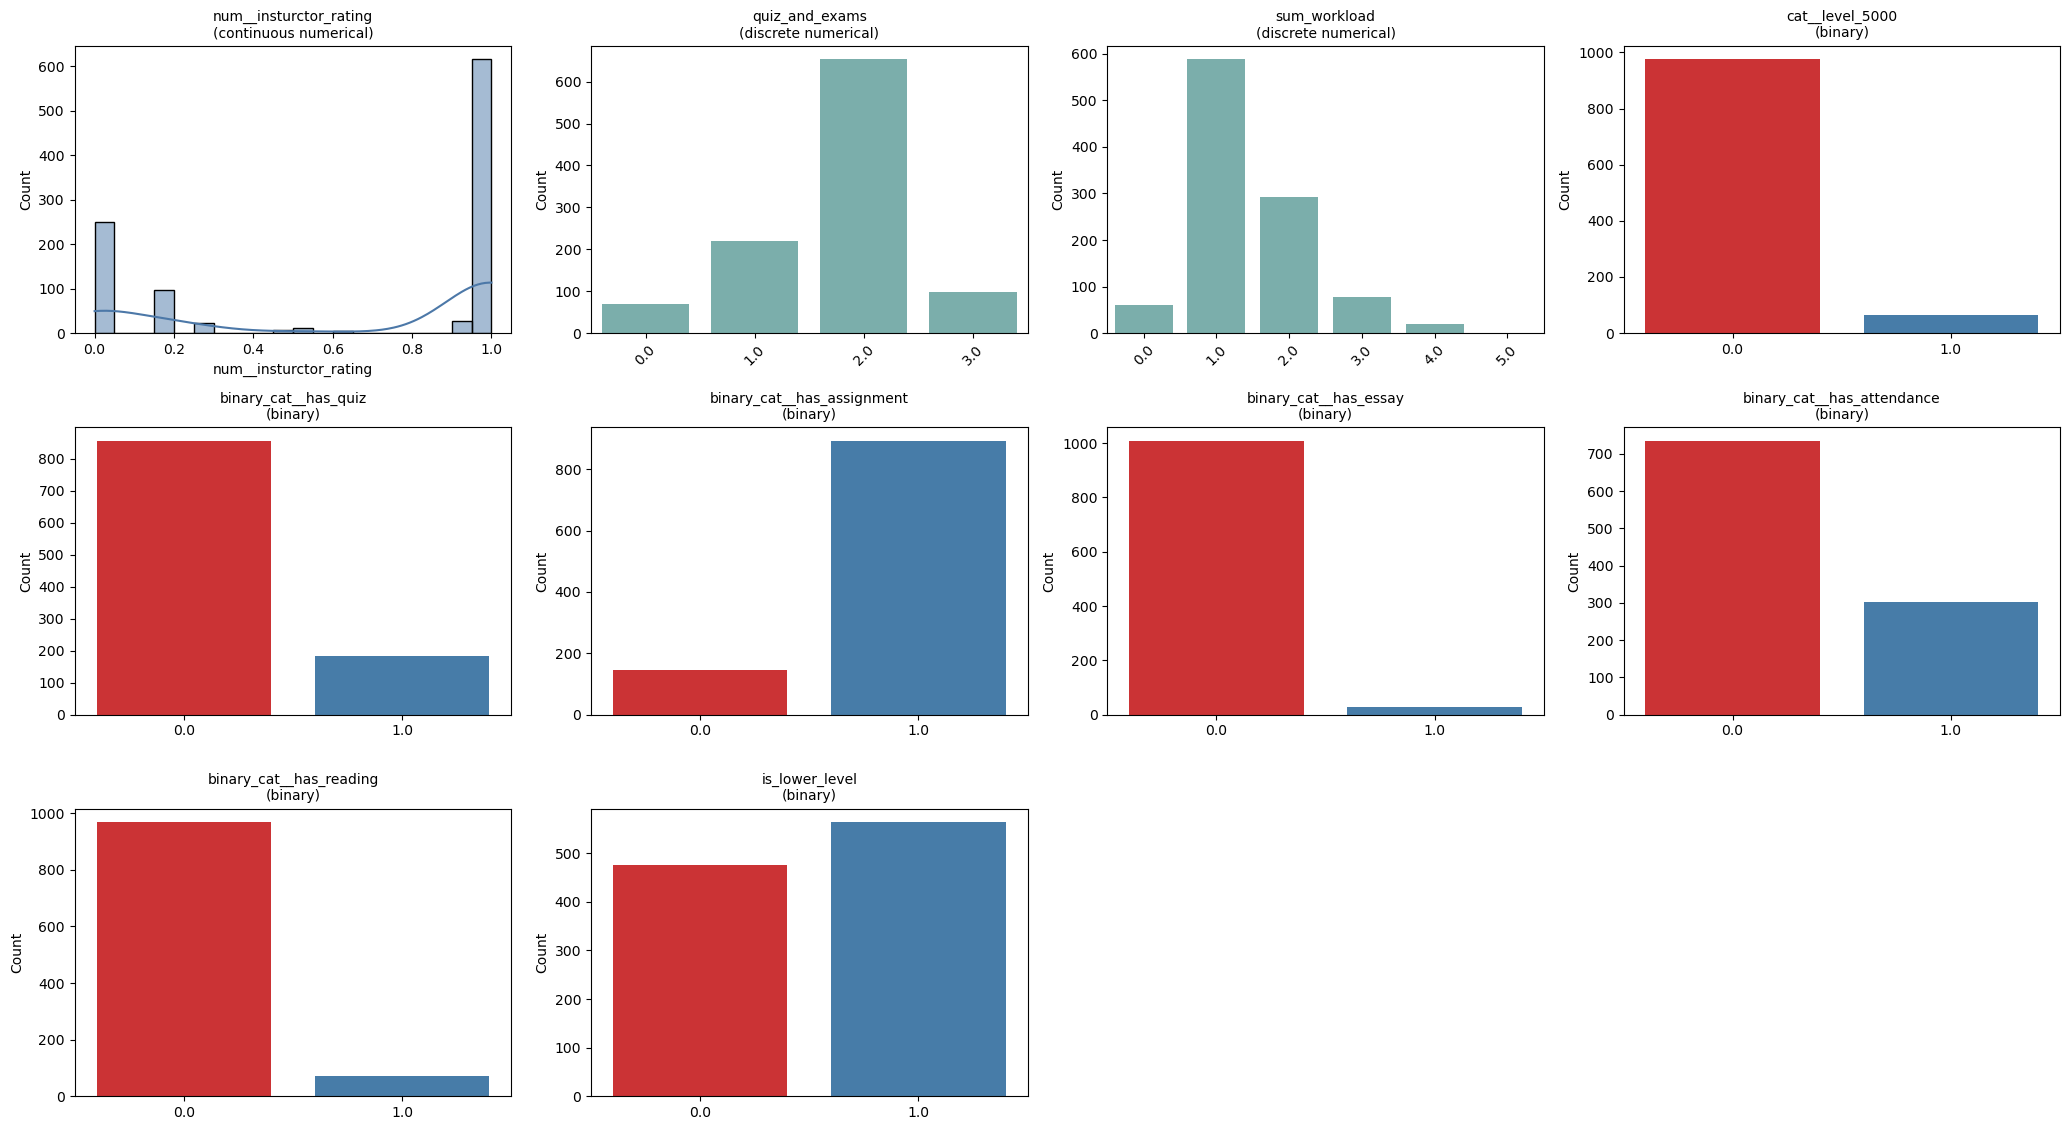

In [31]:
import numpy as np
import math

# Classify features by type
binary_features = [c for c in df_engineered.columns if df_engineered[c].dropna().nunique() <= 2]
categorical_features = [
    c
    for c in df_engineered.columns
    if str(df_engineered[c].dtype) in ["object", "category"] and c not in binary_features
]
numerical_features = [
    c
    for c in df_engineered.columns
    if pd.api.types.is_numeric_dtype(df_engineered[c]) and c not in binary_features
]

# Treat integer-like, low-cardinality numeric features as discrete and use bar plots for them
max_discrete_levels = 10
discrete_numerical_features = []
for c in numerical_features:
    values = df_engineered[c].dropna()
    unique_count = values.nunique()
    is_integer_like = np.all(np.isclose(values, np.round(values)))
    if is_integer_like and unique_count <= max_discrete_levels:
        discrete_numerical_features.append(c)

continuous_numerical_features = [
    c for c in numerical_features if c not in discrete_numerical_features
]

feature_order = continuous_numerical_features + discrete_numerical_features + categorical_features + binary_features
n_features = len(feature_order)

if n_features == 0:
    print("No features found in df_engineered.")
else:
    ncols = 4
    nrows = math.ceil(n_features / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.2 * ncols, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(feature_order):
        ax = axes[i]
        series = df_engineered[col]

        if col in continuous_numerical_features:
            sns.histplot(series.dropna(), kde=True, bins=20, ax=ax, color="#4C78A8")
            ax.set_title(f"{col}\n(continuous numerical)", fontsize=10)
            ax.set_ylabel("Count")

        elif col in discrete_numerical_features:
            counts = series.value_counts(dropna=False).sort_index()
            sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, color="#72B7B2")
            ax.set_title(f"{col}\n(discrete numerical)", fontsize=10)
            ax.tick_params(axis="x", rotation=45)
            ax.set_xlabel("")
            ax.set_ylabel("Count")

        elif col in categorical_features:
            order = series.value_counts(dropna=False).index
            sns.countplot(x=series, order=order, hue=series, legend=False, ax=ax, palette="Set2")
            ax.set_title(f"{col}\n(categorical)", fontsize=10)
            ax.tick_params(axis="x", rotation=45)
            ax.set_xlabel("")
            ax.set_ylabel("Count")

        else:  # binary feature
            order = sorted(series.dropna().unique())
            sns.countplot(x=series, order=order, hue=series, legend=False, ax=ax, palette="Set1")
            ax.set_title(f"{col}\n(binary)", fontsize=10)
            ax.set_xlabel("")
            ax.set_ylabel("Count")

    # Hide any unused subplot panels
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [34]:
# Most instructors seem to have either a very high or low rating, resulting in a bimodal distribution. Perhaps binning can be helpful to cleanly distinguish the two peaks.
df_engineered['is_instructor_rating_high'] = (df_engineered['num__insturctor_rating'] > 0.5)
df_engineered.drop('num__insturctor_rating', axis=1, inplace=True)

# It might also be better to exclude the features 'level_5000', 'has_essay', and/or 'has_reading' as they are highly unbalanced and may not provide much useful insights. But this should be done in the hyperparameter tuning section later on.

In [35]:
df_engineered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cat__level_5000             1038 non-null   float64
 1   binary_cat__has_quiz        1038 non-null   float64
 2   binary_cat__has_assignment  1038 non-null   float64
 3   binary_cat__has_essay       1038 non-null   float64
 4   binary_cat__has_attendance  1038 non-null   float64
 5   binary_cat__has_reading     1038 non-null   float64
 6   quiz_and_exams              1038 non-null   float64
 7   is_lower_level              1038 non-null   float64
 8   sum_workload                1038 non-null   float64
 9   is_instructor_rating_high   1038 non-null   bool   
dtypes: bool(1), float64(9)
memory usage: 74.1 KB


# Model the Data